In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2026-09-12 10:41:35.457305: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-12 10:41:35.806502: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-12 10:41:41.200039: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [3]:
datasetPath = "dataset/10p/all/kernel3/"

In [4]:
# Parameters
datasetPath = "dataset/mask5/10p/glcm/kernel4/"


In [5]:
# train/validation/test = 70/10/20
train_data = pd.read_csv(f"{datasetPath}dataset.train.csv")
validation_data = pd.read_csv(f"{datasetPath}dataset.validation.csv")
test_data = pd.read_csv(f"{datasetPath}dataset.test.csv")

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

2026-09-12 10:41:53.381268: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-09-12 10:41:53.382456: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
import keras

In [8]:
%%time

# Train a Random Forest model.
model = tfdf.keras.RandomForestModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmp4cwg9llb as temporary training directory


Reading training dataset...


Training dataset read in 0:00:02.628284. Found 7617 examples.


Training model...


Model trained in 0:00:00.516091


Compiling model...


[INFO 26-09-12 10:41:56.6036 UTC kernel.cc:1233] Loading model from path /tmp/tmp4cwg9llb/model/ with prefix a73113ff43864d81
[INFO 26-09-12 10:41:56.6892 UTC decision_forest.cc:734] Model loaded with 300 root(s), 63996 node(s), and 24 input feature(s).
[INFO 26-09-12 10:41:56.6893 UTC abstract_model.cc:1362] Engine "RandomForestOptPred" built
[INFO 26-09-12 10:41:56.6893 UTC kernel.cc:1061] Use fast generic engine


Model compiled.


CPU times: user 9.64 s, sys: 150 ms, total: 9.79 s
Wall time: 6.3 s


In [9]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

1/2 [==============>...............] - ETA: 2s - loss: 0.0000e+00 - accuracy: 0.9920

2/2 [==============================] - 3s 8ms/step - loss: 0.0000e+00 - accuracy: 0.9926



loss: 0.0000
accuracy: 0.9926


In [10]:
# Model Summary
model.summary()

Model: "random_forest_model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


Total params: 1 (1.00 Byte)


Trainable params: 0 (0.00 Byte)


Non-trainable params: 1 (1.00 Byte)


_________________________________________________________________


Type: "RANDOM_FOREST"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (24):
	Autocorrelation
	ClusterProminence
	ClusterShade
	ClusterTendency
	Contrast
	Correlation
	DifferenceAverage
	DifferenceEntropy
	DifferenceVariance
	Id
	Idm
	Idmn
	Idn
	Imc1
	Imc2
	InverseVariance
	JointAverage
	JointEnergy
	JointEntropy
	MCC
	MaximumProbability
	SumAverage
	SumEntropy
	SumSquares

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.         "SumAverage"  0.191127 ################
    2.       "JointAverage"  0.189629 ###############
    3.    "Autocorrelation"  0.183301 ##############
    4.    "InverseVariance"  0.136901 #####
    5.               "Imc1"  0.133379 ####
    6.                "MCC"  0.131193 ####
    7.         "SumEntropy"  0.126838 ###
    8.        "Correlation"  0.126349 ###
    9.                "Idn"  0.121422 ##
   10.                 "Id"  0.121135 ##
   11.        "JointEnergy"  0.120702 ##
   12.               "Idmn"  0.120482 ##
   13.         

In [11]:
# Model features
model.make_inspector().features()

["Autocorrelation" (1; #0),
 "ClusterProminence" (1; #1),
 "ClusterShade" (1; #2),
 "ClusterTendency" (1; #3),
 "Contrast" (1; #4),
 "Correlation" (1; #5),
 "DifferenceAverage" (1; #6),
 "DifferenceEntropy" (1; #7),
 "DifferenceVariance" (1; #8),
 "Id" (1; #9),
 "Idm" (1; #10),
 "Idmn" (1; #11),
 "Idn" (1; #12),
 "Imc1" (1; #13),
 "Imc2" (1; #14),
 "InverseVariance" (1; #15),
 "JointAverage" (1; #16),
 "JointEnergy" (1; #17),
 "JointEntropy" (1; #18),
 "MCC" (1; #19),
 "MaximumProbability" (1; #20),
 "SumAverage" (1; #21),
 "SumEntropy" (1; #22),
 "SumSquares" (1; #23)]

In [12]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("SumAverage" (1; #21), 0.1911273747141795),
  ("JointAverage" (1; #16), 0.18962906463006227),
  ("Autocorrelation" (1; #0), 0.1833008841783785),
  ("InverseVariance" (1; #15), 0.13690071121700773),
  ("Imc1" (1; #13), 0.13337949683515335),
  ("MCC" (1; #19), 0.1311926156251137),
  ("SumEntropy" (1; #22), 0.126838446863249),
  ("Correlation" (1; #5), 0.1263486491717629),
  ("Idn" (1; #12), 0.12142180800380926),
  ("Id" (1; #9), 0.12113513783934596),
  ("JointEnergy" (1; #17), 0.12070189048169823),
  ("Idmn" (1; #11), 0.12048189105317036),
  ("Imc2" (1; #14), 0.1199935821941065),
  ("Idm" (1; #10), 0.1188353578143632),
  ("ClusterShade" (1; #2), 0.11871724503676338),
  ("DifferenceAverage" (1; #6), 0.11722173469255519),
  ("MaximumProbability" (1; #20), 0.11688252214452591),
  ("JointEntropy" (1; #18), 0.11339688585300448),
  ("Contrast" (1; #4), 0.11339374681512318),
  ("DifferenceEntropy" (1; #7), 0.11320911999968622),
  ("DifferenceVariance" (1; #8), 0.1121287

In [13]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=7617, accuracy=0.8805546890986116, loss=0.28914240671520763, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

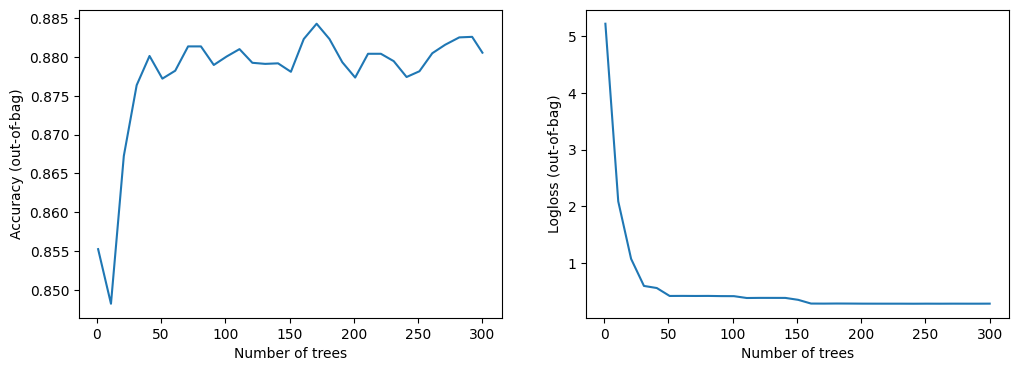

In [14]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

1/2 [==============>...............] - ETA: 0s

2/2 [==============================] - 0s 3ms/step


The ROC AUC score is 0.99927


In [16]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

1/3 [=========>....................] - ETA: 0s

3/3 [==============================] - 0s 9ms/step


Sklearn binary metrics:
accuracy: 0.9667
precision: 0.8912
recall: 0.7577
f1: 0.8190
mcc: 0.8040
roc_auc: 0.9792
pr_auc: 0.8996
log_loss: 0.0985
brier_score: 0.0259

Confusion matrix:
 [[2035   21]
 [  55  172]]

Classification report:
               precision    recall  f1-score   support

           0     0.9737    0.9898    0.9817      2056
           1     0.8912    0.7577    0.8190       227

    accuracy                         0.9667      2283
   macro avg     0.9324    0.8737    0.9004      2283
weighted avg     0.9655    0.9667    0.9655      2283

